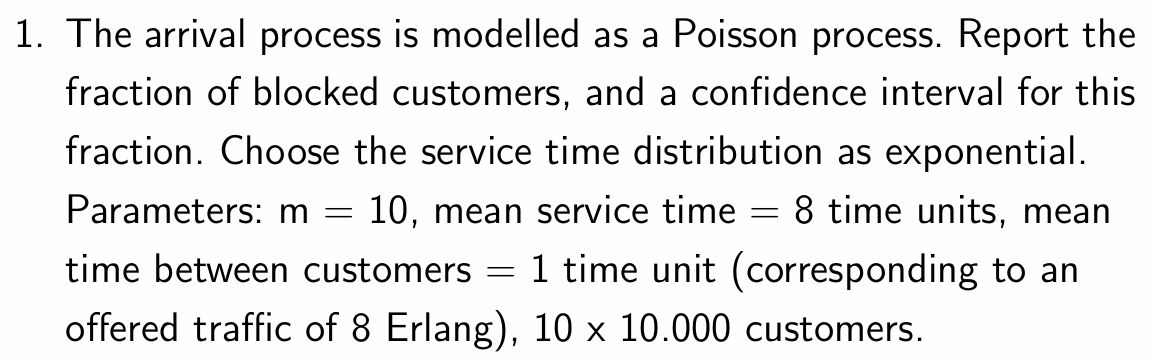

In [ ]:
import scipy.stats as stats
import numpy as np
m = 10
mst = 8
mtvc = 1

n = 10000
block_fractions = []
for i in range(0,m):
    blocked = 0
    # Simulate 10000 arrivals using 8 Erlang distribution
    arrivals = stats.poisson.rvs(mu=mst, size=n)
    for arrival in arrivals:
        # Generate next time interval from Exp(mtsv, 1)
        next_interval = stats.expon.rvs(scale=mtvc, size=1)
        # remove all completed services (depatures before arrival time)
        arrivals = arrivals[next_interval > arrivals]
        # If fewer than m in service, accept customer, generate service time from Exp(mean, 8), store departure time
        if len(arrivals) < m:
            service_time = stats.expon.rvs(scale=mst*mtvc, size=1)
            departure_time = next_interval + service_time
            # Store departure time for next iteration
        else:
            blocked += 1
    block_fractions.append(blocked / n)
print(block_fractions)
print("Mean Blocking Fraction:", np.mean(block_fractions))
print(f"Confidence Interval: {np.mean(block_fractions)} ± {1.96 * np.std(block_fractions) / np.sqrt(len(block_fractions))}")

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Mean Blocking Fraction: 1.0
Confidence Interval: 1.0 ± 0.0


In [5]:
import numpy as np
import heapq
from scipy.stats import t as student_t

# Parameters from the exercise
m = 10                      # number of servers
mean_service_time = 8.0     # E[S]
mean_interarrival = 1.0     # E[A]
n_customers = 10_000        # per replication
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []  # min-heap of service completion times for customers in service

    for _ in range(n_customers):
        # Poisson arrivals <=> exponential interarrival times
        t_now += rng.exponential(scale=mean_interarrival)

        # Remove all customers that have completed service before this arrival
        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        # If a server is free, accept; otherwise block
        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

# 95% CI across replications (t-interval)
mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

# Erlang-B theoretical blocking probability for M/M/m/m
lam = 1.0 / mean_interarrival
A = lam * mean_service_time  # offered traffic in Erlang

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1217, 0.1182, 0.1186, 0.1271, 0.1253, 0.1232, 0.131, 0.1196, 0.118, 0.1186]
Mean blocking fraction: 0.122130
95% CI: [0.118943, 0.125317]
Erlang-B theoretical blocking: 0.121661


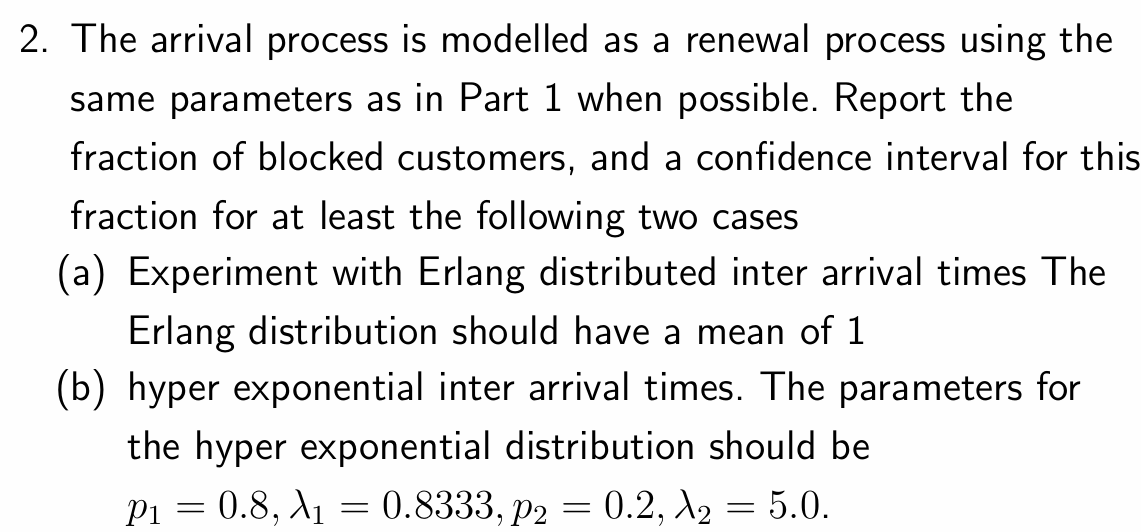

### (a) Erlang distributed arrival times.
In this exercise, we change the exponentially distributed arrival times to Erlang distributed with mean 1 (loc = 1)

In [8]:
import numpy as np
import heapq
from scipy.stats import t as student_t
import scipy.stats as stats

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        t_now += rng.exponential(scale=mean_interarrival)

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = stats.erlang.rvs(a=mean_service_time, scale=1.0, random_state=rng)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.1206, 0.1184, 0.1177, 0.1238, 0.1262, 0.1283, 0.124, 0.1232, 0.1277, 0.128]
Mean blocking fraction: 0.123790
95% CI: [0.121011, 0.126569]
Erlang-B theoretical blocking: 0.121661


### (b) hyperexponential inter arrival time
We make the same changes but instead use a hyperexponential distribution instead. The hyperexponential is defined as:

$$F(x) = \sum_{i=1}^mp_i(1-e^{\lambda_ix})$$

In [ ]:
import numpy as np
import heapq
from scipy.stats import t as student_t
import scipy.stats as stats

m = 10
mean_service_time = 8.0
mean_interarrival = 1.0
n_customers = 10_000
n_replications = 10

rng = np.random.default_rng(42)

block_fractions = []

lambda1 = 0.8333
lambda2 = 5.0
p1 = 0.8

for _ in range(n_replications):
    t_now = 0.0
    blocked = 0
    departures = []

    for _ in range(n_customers):
        if rng.random() < p1:
            interarrival = rng.exponential(scale=1 / lambda1)
        else:
            interarrival = rng.exponential(scale=1 / lambda2)
        t_now += interarrival

        while departures and departures[0] <= t_now:
            heapq.heappop(departures)

        if len(departures) < m:
            service_time = rng.exponential(scale=mean_service_time)
            heapq.heappush(departures, t_now + service_time)
        else:
            blocked += 1

    block_fractions.append(blocked / n_customers)

block_fractions = np.array(block_fractions)

mean_block = block_fractions.mean()
s = block_fractions.std(ddof=1)
tcrit = student_t.ppf(0.975, df=n_replications - 1)
half_width = tcrit * s / np.sqrt(n_replications)

lam = 1.0 / mean_interarrival
A = lam * mean_service_time

B = 1.0
for k in range(1, m + 1):
    B = (A * B) / (k + A * B)

print("Replication blocking fractions:", block_fractions.tolist())
print(f"Mean blocking fraction: {mean_block:.6f}")
print(f"95% CI: [{mean_block - half_width:.6f}, {mean_block + half_width:.6f}]")
print(f"Erlang-B theoretical blocking: {B:.6f}")

Replication blocking fractions: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Mean blocking fraction: 0.000000
95% CI: [0.000000, 0.000000]
Erlang-B theoretical blocking: 0.121661
